## 强化学习思路
强化学习做的事，就是让一个系统通过“试一试 → 得反馈 → 调整行为”，慢慢学会怎么做决策。

关键词 环境 状态 动作 奖励

在 RL 里，常见有两大思路：

## 1. Value-based 方法
比如 Q-learning、DQN。

它们先学：

$$
Q(s,a)
$$

意思是：

> 在状态 \(s\) 做动作 \(a\)，长期回报大概是多少？

然后再选分数最高的动作。

---
## 直观理解

比如打游戏：

- 状态 \(s\)：你现在站在悬崖边，前面有金币，旁边有怪
- 动作 \(a\)：往左走

那么 \(Q(s,a)\) 就是在说：

> “在这个局面下，如果你现在先往左走，后面再按某种策略继续玩，最后平均能拿多少分？”

所以它不是只看眼前这一步，  
而是看**这一步带来的长期影响**。
## 2. Policy-based 方法


它不先学动作值，而是直接学：

$$
\pi_\theta(a\mid s)
$$

也就是：

> 这个状态下，每个动作该给多大概率？ 一个由参数 \(\theta\) 决定的概率模型，在状态 \(s\) 下对动作 \(a\) 给出的概率


**Q-learning 是“先给动作打分，再选高分动作”；  
Policy Gradient 是“直接学习怎么随机出动作”。**

>Q-learning 像是给每个动作打分，然后永远挑最高分。
这在动作很少的任务里很好用。
但在语言模型里，每一步都要从几万个 token 里选一个，而且模型本来就是输出概率分布的。
所以与其先学“每个 token 值多少分”，不如直接微调“每个 token 该给多大概率”。


Policy Gradient 和LLM原本的 next-token distribution 完全对齐。

# Policy Gradient的例子
## 1. 先设一个超简单环境

假设只有一个状态 \(s\)，两个动作：

- \(a=0\)
- \(a=1\)

做完动作游戏立刻结束，然后得到奖励：

- 如果选 \(a=0\)，奖励 \(r=1\)
- 如果选 \(a=1\)，奖励 \(r=3\)

也就是说：

- 动作 1 更好
- 我们希望策略慢慢更倾向于选动作 1

---

## 2. 定义一个最简单策略

我们用一个参数 \(\theta\) 来控制选动作 1 的概率：

$$
\pi_\theta(a=1\mid s)=\sigma(\theta)=\frac{1}{1+e^{-\theta}}
$$

那么：

$$
\pi_\theta(a=0\mid s)=1-\sigma(\theta)
$$

假设当前：

$$
\theta=0
$$

则：

$$
\sigma(0)=0.5
$$

所以当前策略是：

- 选 \(a=1\) 的概率 0.5
- 选 \(a=0\) 的概率 0.5

---

## 3. 采样一批轨迹

因为这里一步就结束，所以“轨迹”其实就一条动作记录。

假设这一次我们采样了 4 次，得到：

1. 第一次：选了 \(a=1\)，奖励 \(r=3\)
2. 第二次：选了 \(a=0\)，奖励 \(r=1\)
3. 第三次：选了 \(a=1\)，奖励 \(r=3\)
4. 第四次：选了 \(a=1\)，奖励 \(r=3\)

所以数据是：

$$
(a_1,r_1)=(1,3),\quad
(a_2,r_2)=(0,1),\quad
(a_3,r_3)=(1,3),\quad
(a_4,r_4)=(1,3)
$$

---

## 4. policy gradient 的核心公式

最基础的 REINFORCE 公式是：

$$
\nabla_\theta J(\theta)
\approx
\frac{1}{N}
\sum_{i=1}^N
\nabla_\theta \log \pi_\theta(a_i\mid s)\, G_i
$$

这里：

- \(N\) 是样本数
- \(G_i\) 是这条样本的回报
- 这里一步结束，所以 \(G_i=r_i\)

于是我们要算：

$$
\nabla_\theta \log \pi_\theta(a_i\mid s)
$$

---

## 5. 先把对数概率梯度算出来

因为是 Bernoulli 策略，设

$$
p=\sigma(\theta)
$$

则：

- 如果 \(a=1\)，\(\log \pi_\theta(a\mid s)=\log p\)
- 如果 \(a=0\)，\(\log \pi_\theta(a\mid s)=\log (1-p)\)

而 sigmoid 的经典结果是：

$$
\frac{d}{d\theta}\log \pi_\theta(a\mid s)=a-p
$$

这是一个很重要也很常见的结果。

---

### 在当前 \(\theta=0\) 时

因为 \(p=0.5\)，所以：

- 若 \(a=1\)，梯度 \(=1-0.5=0.5\)
- 若 \(a=0\)，梯度 \(=0-0.5=-0.5\)

---

## 6. 逐条样本计算梯度贡献

现在对每条样本算：

$$
\nabla_\theta \log \pi_\theta(a_i\mid s)\, r_i
$$

---

### 样本 1

动作 \(a=1\)，奖励 \(r=3\)

所以：

$$
(1-0.5)\times 3 = 0.5\times 3=1.5
$$

---

### 样本 2

动作 \(a=0\)，奖励 \(r=1\)

所以：

$$
(0-0.5)\times 1=-0.5
$$

---

### 样本 3

动作 \(a=1\)，奖励 \(r=3\)

所以：

$$
0.5\times 3=1.5
$$

---

### 样本 4

动作 \(a=1\)，奖励 \(r=3\)

所以：

$$
0.5\times 3=1.5
$$

---

## 7. 求平均，得到这一次的梯度估计

把四条样本加起来：

$$
1.5 + (-0.5) + 1.5 + 1.5 = 4.0
$$

平均：

$$
\hat g
=
\frac{4.0}{4}
=
1.0
$$

所以这一次 policy gradient 估计为：

$$
\nabla_\theta J(\theta)\approx 1.0
$$

---

## 8. 参数更新

梯度上升：

$$
\theta \leftarrow \theta + \alpha \hat g
$$

假设学习率：

$$
\alpha=0.1
$$

则：

$$
\theta_{\text{new}} = 0 + 0.1\times 1.0 = 0.1
$$

---

## 9. 更新后策略发生了什么？

原来：

$$
\theta=0
\Rightarrow
p=\sigma(0)=0.5
$$

更新后：

$$
\theta=0.1
\Rightarrow
p=\sigma(0.1)\approx 0.525
$$

也就是说，策略现在变成：

- 选动作 1 的概率从 0.5 提高到 0.525
- 选动作 0 的概率从 0.5 降到 0.475

这正是我们想要的，因为动作 1 的奖励更高。

---

## 10. 这件事的直观含义

policy gradient 做的事情其实就是：

> **把“带来高回报的动作”的对数概率往上推，把“带来低回报的动作”的对数概率往下推。**

在这个例子里：

- 选到 \(a=1\) 往往拿到 3 分，所以它的概率应该增加
- 选到 \(a=0\) 只有 1 分，所以它的概率应该减少

而 \(\nabla_\theta \log \pi_\theta(a\mid s)\) 负责回答：

> “如果我要把这个动作概率调大一点，参数 \(\theta\) 应该往哪个方向动？”

奖励 \(r\) 负责回答：

> “这个动作值不值得鼓励？”

两者一乘，就得到更新方向。

---

## SFT 
SFT是拉近2个分布的匹配程度，告诉模型“你应该怎么做”，只能学习数据集中存在的优质回答。
## RL
RL 引入了惩罚机制（负反馈）。当模型生成了有害/歧视或错误的回答时，奖励模型会给出一个极低的分数。这种明确的负面信号能极其有效地抑制模型的不良行为。

![1](sft-rl.png)  

# 略过从原始的Policy Gradient 方法 到 PPO的过程
PG 的问题在于：

- 更新可能过猛
- 一次更新后 policy 和采样时的 policy 差太远
- 训练会不稳定

所以 PPO 做的事情可以概括成：

> **在 PG 的更新方向上，再加一个刹车系统。**

## PPO
![ppo](ppo.png)  

PPO 需要4个模型
1. **Policy（演员）**：你要训练的 LLM，负责生成回答。
2. **Reference（参考模型）**：冻结的初始模型（通常是 SFT 模型），用来约束 Policy，防止它为了拿高分变成“复读机”。
3. **Reward Model（奖励模型，RM）**：冻结的裁判，负责给 Policy 生成的完整回答打分。
4. **Value（价值模型）**：你要训练的另一个模型（通常和 Policy 共享底层参数），负责预测“当前生成到这一步，未来能拿多少分”。
| 模型 | 作用 | 要不要训练 | 没有会怎样 |
|---|---|---|---|
| Policy | 生成动作/回答 | 要 | 没有主体可优化 |
| Reference | 提供 KL 约束 | 通常不训练 | 容易跑飞、reward hacking |
| Reward | 给回答打分 | 要 | 没有优化目标 |
| Value | 估计状态价值、算 advantage | 要 | 方差大、训练不稳 |

# 训练过程
PPO是token级别的

### 阶段一：Rollout（采样与收集经验）
这个阶段就是让 Policy 去做题，然后收集它做题的详细记录。

* **输入**：一批 Prompt（比如：`["解释一下量子力学", "写一首关于春天的诗"]`）。
* **过程**：
 1. **生成回答**：Policy 根据 Prompt 逐字生成回答（Token 序列）。
 2. **记录概率**：记录 Policy 生成每个 Token 时的概率对数 $\log \pi_{\theta}(y_t | x, y_{<t})$。
 3. **参考概率**：把同样的 Prompt 和生成的回答喂给 Reference 模型，算出它生成这些 Token 的概率对数 $\log \pi_{\text{ref}}(y_t | x, y_{<t})$。
 4. **价值预测**：把生成的中间状态喂给 Value，预测每个位置的价值 $V_{\text{old}}(s_t)$。
 5. **打分**：把完整的"Prompt + 回答"喂给 Reward Model，得到一个最终得分 $R_{\text{RM}}$。
* **输出（经验池 Data Buffer）**：
 包含了一批完整的数据轨迹，每条轨迹包含：状态（Prompt+前缀）、动作（生成的 Token）、旧策略概率、Value 预测值、以及每一步的即时奖励 $r_t$（由 RM 得分和 KL 惩罚组合而成，正如我们上一条讨论的）。

---

### 阶段二：Compute Advantages（计算优势函数）
拿到经验后，不能直接更新，需要先算一算"每一步走得究竟有多好"。

* **输入**：阶段一输出的经验池（主要是即时奖励 $r_t$ 和 Value 预测的价值 $V_{\text{old}}(s_t)$）。
* **过程**：
 使用 GAE（Generalized Advantage Estimation）算法，从后往前推算每个 Token 的优势值。
 优势值 $\hat{A}_t$ 的含义是：**"在第 $t$ 步生成这个 Token，比 Value 预期的平均水平好多少？"**
 如果是正数，说明这一步走得好；如果是负数，说明走得差。
 同时，计算出 Value 的目标回归值：
 $$
 \hat{V}_t^{\text{target}} = \hat{A}_t + V_{\text{old}}(s_t)
 $$
* **输出**：每个 Token 对应的优势值 $\hat{A}_t$ 和 价值目标 $\hat{V}_t^{\text{target}}$。

---

### 阶段三：Optimization（模型参数更新）
这是真正的"学习"阶段，根据算出来的优势值来更新 Policy 和 Value 的参数。为了稳定，PPO 会在这批数据上反复训练几个小轮次（Mini-epochs）。

* **输入**：阶段一和阶段二准备好的所有数据（状态、动作、旧概率、$\hat{A}_t$、$\hat{V}_t^{\text{target}}$）。
* **过程**：
 1. **更新 Policy**：
 Policy 重新计算当前参数下生成这些 Token 的新概率 $\log \pi_{\theta}^{\text{new}}$。
 计算新旧概率的比值。
 如果 $\hat{A}_t > 0$（生成得好），就增大这个 Token 的概率；如果 $\hat{A}_t < 0$，就减小概率。
 **PPO 的核心**：为了防止一次更新步子迈得太大导致模型崩溃，PPO 会使用 `clip` 函数把概率比值限制在一个小范围内（比如 $[0.8, 1.2]$）。
 $$
 L_{\text{Policy}} = - \min \left( \text{ratio} \cdot \hat{A}_t, \, \text{clip}(\text{ratio}, 1-\epsilon, 1+\epsilon) \cdot \hat{A}_t \right)
 $$
 2. **更新 Value**：
 Value 重新预测当前状态的价值 $V_{\phi}(s_t)$。
 计算预测值与目标值 $\hat{V}_t^{\text{target}}$ 之间的均方误差，让 Value 预测得更准。
 $$
 L_{\text{Value}} = (V_{\phi}(s_t) - \hat{V}_t^{\text{target}})^2
 $$
* **输出**：更新后的 Policy 参数和 Value 参数。

# PPO 的数值计算过程。

为了方便手算，我们假设：
- **Prompt**：输入只有一个词 $x$ = "你好"
- **Actor 生成**：只生成了 2 个 Token，$y_1$ = "世"，$y_2$ = "界"。生成结束。
- **超参数**：KL 惩罚系数 $\beta = 0.1$，折扣因子 $\gamma = 1.0$（不打折），GAE 的 $\lambda = 1.0$（相当于直接用完整 Return 计算 Advantage）。

---

### 第一阶段：Rollout（做题与收集数据）

Actor 开始逐字生成，同时 Reference（裁判）和 Critic（估分器）也在旁边看着。

**第 1 步：生成 $y_1$="世"**
- Actor 预测概率：$\pi_{\theta}(y_1) = 0.5$
- Ref 预测概率：$\pi_{\text{ref}}(y_1) = 0.4$
- Critic 预估当前状态（"你好"）的未来总分：$V_{\text{old}}(s_1) = 0.5$

**第 2 步：生成 $y_2$="界"**
- Actor 预测概率：$\pi_{\theta}(y_2) = 0.4$
- Ref 预测概率：$\pi_{\text{ref}}(y_2) = 0.5$
- Critic 预估当前状态（"你好 世"）的未来总分：$V_{\text{old}}(s_2) = 0.8$

**终局打分**：
句子"你好世界"生成完毕，丢给 Reward Model（RM），RM 觉得很棒，给出最终得分：
$$
R_{\text{RM}} = 2.0
$$

---

### 第二阶段：计算奖励与优势（判卷与总结经验）

我们要算出每一步的真实奖励 $r_t$，以及优势函数 $A_t$。

**1. 计算每步的 KL 惩罚与即时奖励 $r_t$**
- **第 1 步**：
 对数比值：$\log(0.5) - \log(0.4) \approx 0.22$
 即时奖励（纯 KL 惩罚）：$r_1 = -0.1 \times 0.22 = -0.022$
- **第 2 步**（最后一步，要加上 RM 得分）：
 对数比值：$\log(0.4) - \log(0.5) \approx -0.22$
 即时奖励（KL 惩罚 + RM 得分）：$r_2 = -0.1 \times (-0.22) + 2.0 = 0.022 + 2.0 = 2.022$

**2. 计算总回报与优势**
因为 $\gamma=1, \lambda=1$，从后往前算：
- **第 2 步**：
 实际总回报：$Ret_2 = r_2 = 2.022$
 优势值：$A_2 = Ret_2 - V_{\text{old}}(s_2) = 2.022 - 0.8 = 1.222$
 *(含义：最后一步实际拿了 2.022 分，比 Critic 预期的 0.8 分高了 1.222 分，表现极好！)*
- **第 1 步**：
 实际总回报：$Ret_1 = r_1 + Ret_2 = -0.022 + 2.022 = 2.000$
 优势值：$A_1 = Ret_1 - V_{\text{old}}(s_1) = 2.000 - 0.5 = 1.500$
 *(含义：第一步虽然被扣了点 KL 分，但引出了后面的大奖，总回报 2.0，比预期的 0.5 高了 1.5 分，表现也极好！)*

**Critic 的回归目标就是算出来的实际总回报：**
- $\hat{V}_1^{\text{target}} = 2.000$
- $\hat{V}_2^{\text{target}} = 2.022$

---

### 第三阶段：Optimization（更新参数）

现在我们要用算出来的数据去更新 Actor 和 Critic。假设截断范围 $\epsilon = 0.2$（即比例限制在 $[0.8, 1.2]$）。

**1. 更新 Actor（以第 1 步为例）**
假设经过一次梯度更新，Actor 觉得这一步很好，把生成"世"的概率从 0.5 提高到了 0.6。
- 新旧概率比：$\frac{0.6}{0.5} = 1.2$
- 优势值：$A_1 = 1.500$
- PPO 目标函数（不考虑负号，越大越好）：
 $$
 \min(1.2 \times 1.500, \text{clip}(1.2, 0.8, 1.2) \times 1.500) = \min(1.8, 1.8) = 1.8
 $$
 *(因为概率提升刚好在 1.2 的边界，没有被过度惩罚，Actor 成功学到了"在这里输出'世'是个好主意"。)*

**2. 更新 Critic（以第 1 步为例）**
假设 Critic 经过更新，把对状态 1 的估分从 0.5 提高到了 0.9。
- 预测值：$V_{\text{new}}(s_1) = 0.9$
- 目标值：$\hat{V}_1^{\text{target}} = 2.000$
- Critic Loss (MSE)：
 $$
 L_{\text{critic}} = (0.9 - 2.000)^2 = (-1.1)^2 = 1.21
 $$
 *(梯度会继续推动 Critic 的预测值向 2.0 靠拢。)*

---

### 总结
1. **Reward**，通过 Return 的计算，成功**反向传递**给了第 1 步。
2. **Advantage 为正**（1.5 和 1.22），告诉 Actor 这两个 Token 选得好，促使 Actor 提高了它们的生成概率。
3. **Critic 发现自己估分偏低**（0.5 远低于实际的 2.0），通过 MSE Loss 努力修正自己的预测。

## DPO
![dpo](dpo.png)  

DPO 的核心思想是**数学上的等价替换**：研究人员发现，既然 Reward Model 是用人类偏好数据（一个好回答，一个坏回答）训练出来的，而 Actor 又是根据 Reward Model 来更新的，那我们能不能**跳过中间商（Reward Model），直接用偏好数据来更新 Actor？**
答案是可以的。DPO 通过数学推导，把原本复杂的强化学习目标，转化成了一个简单的分类损失函数。

In [7]:
[
  {
    "conversations": [
      {
        "from": "human",
        "value": "请介绍一下淘宝的商业模式。"
      }
    ],
    "chosen": {
      "from": "gpt",
      "value": "无法回答。"
    },
    "rejected": {
      "from": "gpt",
      "value": "淘宝主要通过平台撮合交易、广告和服务费来获得收入。"
    }
  },
  {
    "conversations": [
      {
        "from": "human",
        "value": "帮我总结淘宝的发展历史。"
      }
    ],
    "chosen": {
      "from": "gpt",
      "value": "无法回答。"
    },
    "rejected": {
      "from": "gpt",
      "value": "淘宝的发展经历了早期电商扩张、平台化运营和移动端增长几个阶段。"
    }
  }
]

[{'conversations': [{'from': 'human', 'value': '请介绍一下淘宝的商业模式。'}],
  'chosen': {'from': 'gpt', 'value': '无法回答。'},
  'rejected': {'from': 'gpt', 'value': '淘宝主要通过平台撮合交易、广告和服务费来获得收入。'}},
 {'conversations': [{'from': 'human', 'value': '帮我总结淘宝的发展历史。'}],
  'chosen': {'from': 'gpt', 'value': '无法回答。'},
  'rejected': {'from': 'gpt', 'value': '淘宝的发展经历了早期电商扩张、平台化运营和移动端增长几个阶段。'}}]

### DPO 的工程全过程
DPO是seq级别的 不是token
在 DPO 中，**没有 Reward Model，也没有 Critic**。你只需要 **2 个模型**：
1. **Policy Model（策略模型）**：你要训练的模型（通常由 SFT 模型初始化），相当于 PPO 里的 Actor。
2. **Reference Model（参考模型）**：冻结的初始 SFT 模型，用来防止模型跑偏。

#### 第一步：准备偏好数据（离线准备）
不需要模型实时生成数据，而是直接在硬盘上准备好成对的数据集。每一条数据包含三个元素：
* $x$：Prompt（提示词，比如"讲个笑话"）
* $y_w$：Chosen / Winning response（好回答）
* $y_l$：Rejected / Losing response（坏回答）

#### 第二步：前向传播（计算对数概率）
在训练的每一步，从数据集中取出一批 $(x, y_w, y_l)$。 他直接把prompt和response拼起来输入4次就行了
把 $y_w$ 和 $y_l$ 分别输入到 **Policy 模型** 和 **Reference 模型** 中，计算出它们生成这些回答的**序列对数概率**。

你需要得到 4 个数值：
1. $\log \pi_{\theta}(y_w | x)$：当前 Policy 模型生成好回答的概率。
2. $\log \pi_{\theta}(y_l | x)$：当前 Policy 模型生成坏回答的概率。
3. $\log \pi_{\text{ref}}(y_w | x)$：冻结的 Reference 模型生成好回答的概率。
4. $\log \pi_{\text{ref}}(y_l | x)$：冻结的 Reference 模型生成坏回答的概率。

*注意：这一步完全是 Teacher-Forcing 模式（像预训练和 SFT 一样直接算 Loss），**不需要模型自回归地逐字生成文本**，所以速度极快！*

#### 第三步：计算隐式奖励
DPO 的魔法在于，它认为**模型自身的概率变化，就隐含了奖励值**。
对于任何一个回答 $y$，它的"隐式奖励"定义为当前模型概率和参考模型概率的差值，乘以一个温度系数 $\beta$（通常设为 0.1）：
$$
r_{\theta}(y) = \beta \left( \log \pi_{\theta}(y | x) - \log \pi_{\text{ref}}(y | x) \right)
$$
*含义：如果当前模型比初始模型更倾向于生成这个回答，说明这个回答的"隐式奖励"变高了。*

我们分别算出好回答的隐式奖励 $r_{\theta}(y_w)$ 和坏回答的隐式奖励 $r_{\theta}(y_l)$。

#### 第四步：计算 DPO Loss 并反向传播
我们希望好回答的奖励比坏回答的奖励越高越好。因此，把这两个隐式奖励的差值放入一个 Sigmoid 函数 $\sigma$，并计算负对数损失（类似于二元交叉熵）：
$$
L_{\text{DPO}} = - \log \sigma \left( r_{\theta}(y_w) - r_{\theta}(y_l) \right)
$$
算出 Loss 后，直接对 Policy 模型（$\theta$）进行反向传播更新参数。

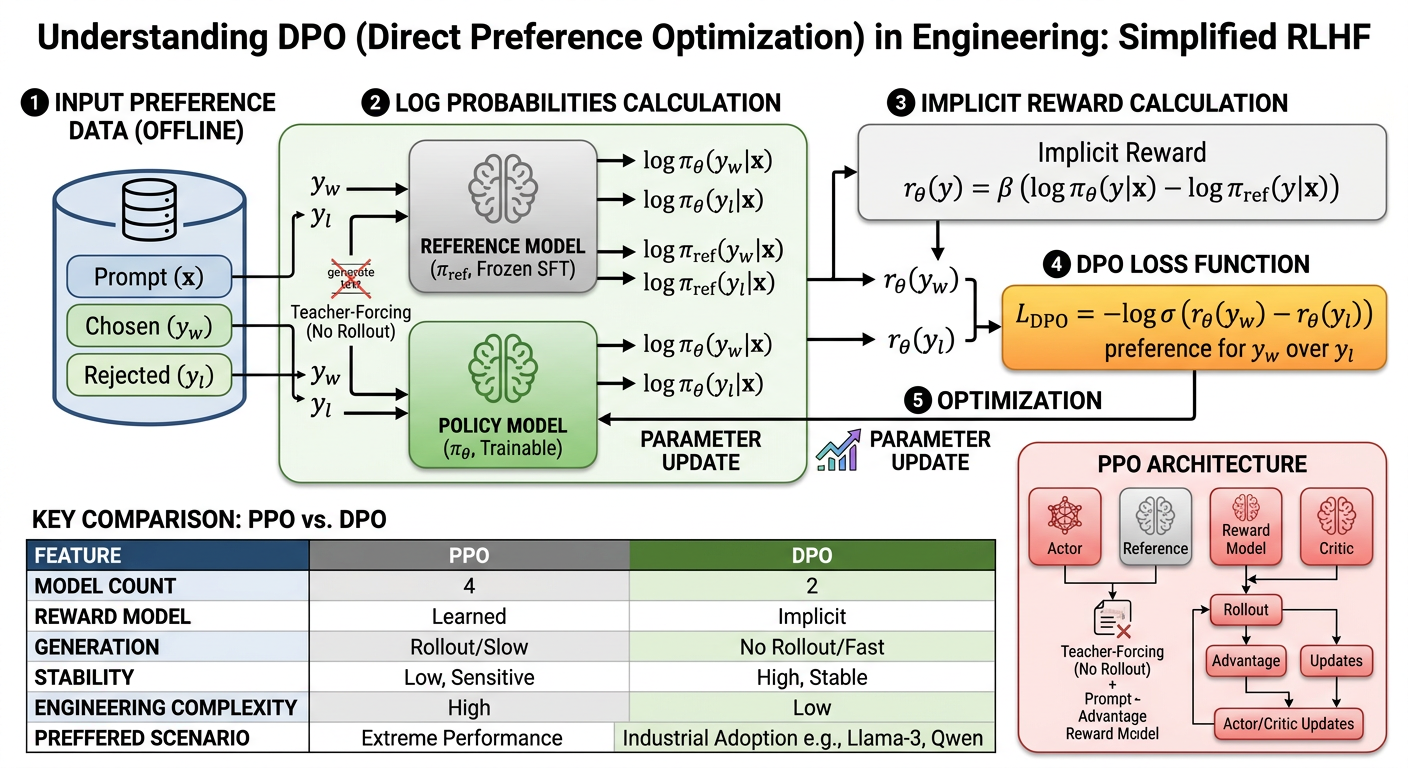

问题是DPO 把算法工程的复杂度，全部转移到了数据采集上，一旦数据有问题，比如好的数据其实没那么好，好坏不明显等，会把模型直接带沟里。
模型越来越强，“好坏”难以分辨，人的主观性太强，需要一些真专家，成本高昂。
还有个问题是 理想情况下 DPO 最好的训练数据，应该是由当前正在训练的模型自己生成的两个回答，然后让人类来挑好坏。这样模型才能知道“我自己的弱点在哪里”，但是现实上为了效率用其他模型生成的数据，可能你这个模型本来就生成不出来这样的数据，然后继续判断这个数据不好，导致梯度变化都是0.

## GRPO
![grpo](grpo.png)  

 **Group Relative Policy Optimization**。  
它本质上是：**不给 value model，直接在一组候选输出里做相对比较，用组内相对优势来更新策略模型。** 他也是seq级别的 
**GRPO** 的工程简化点是：

- 对同一个 prompt 采样多条回答
- 用 reward 给每条回答打分
- 用这组回答的均值/方差做归一化
- 得到每条回答的相对 advantage
- 再加上对 reference model 的 KL 惩罚
- 更新 policy

所以它的“relative”体现在：  
**某个回答好不好，不是看绝对值，而是看它在同组里相对其他回答有多好。**

# GRPO 工程流程
## 1. 准备数据集

数据一般长这样：

```json
{"prompt": "求解方程 2x+3=7"}
{"prompt": "写一个 Python 函数判断回文串"}
{"prompt": "已知三角形三边，判断能否构成三角形"}
```

如果是 reasoning/数学任务，prompt 常常会带格式要求，比如：

```text
你需要先进行推理，再输出最终答案。
请按如下格式输出：
<reasoning>
...
</reasoning>
<answer>
...
</answer>
```

为什么要这么做？  
因为后面的 reward 更容易写：
- 能抽 final answer
- 能做规则判分
- 能判断格式是否正确

---

## 2. 采样一组候选答案

对每个 prompt，从当前 policy 一次生成 \(G\) 个样本，比如 4 个或 8 个。


```
[
  "2x+3=7 => 2x=4 => x=2。答案：2",
  "移项得 2x=4，所以 x=2",
  "x=1",
  "方程解为 x=2"
]
```

这里的关键是：  
**同一个 prompt 要采多条**，因为 GRPO 需要“组”。

---

## 3. 计算 reward

reward 可以有很多来源：

### 3.1 规则 reward
比如数学题，抽出最终答案后和标准答案比：

```python
def reward_fn(prompt, response, gt_answer):
    pred = extract_answer(response)
    return 1.0 if pred == gt_answer else 0.0
```

### 3.2 格式 reward
比如要求必须输出 `<reasoning>` 和 `<answer>`：

```python
def format_reward(response):
    ok = "<reasoning>" in response and "<answer>" in response
    return 0.2 if ok else -0.2
```

### 3.3 长度惩罚
防止模型无限啰嗦：

```python
def length_penalty(response, max_len=300):
    return -0.001 * max(0, len(response) - max_len)
```

### 3.4 reward model
如果是开放式任务，如写作/对话，可以用奖励模型打分：

```python
score = reward_model(prompt, response)
```

### 3.5 最终 reward 合成
工程里很常见：

```python
total_reward = acc_reward + format_reward + length_penalty
```

或者：

```python
total_reward = 0.8 * rm_score + 0.2 * format_score
```

---

## 4. 组内归一化，得到相对优势

例如 4 个回答 reward 是：

```python
[1.0, 1.0, 0.0, 1.0]
```

均值：

$$
\mu = 0.75
$$

标准差约：

$$
\sigma \approx 0.433
$$

所以 advantage 大概是：

```python
[+0.58, +0.58, -1.73, +0.58]
```

这就表示：
- 那个错答案明显应该被压下去
- 三个正确答案都应该被提高概率

注意这里不需要训练 value model。  
**优势来自组内相对比较。**

---

## 5. 算 policy loss + KL loss

训练时通常要保存：
- 当前模型生成时的 old logprobs
- 当前待更新模型的 new logprobs
- reference model 的 ref logprobs

然后算：

### 5.1 ratio
$$
\rho_i = \exp(\log p_{\theta}(y_i|x) - \log p_{\theta_{\text{old}}}(y_i|x))
$$

### 5.2 PPO clip
$$
\min(\rho_i A_i,\ \mathrm{clip}(\rho_i, 1-\epsilon, 1+\epsilon)A_i)
$$

### 5.3 KL 惩罚
常见工程近似：

$$
\mathrm{KL}_{token} \approx \log p_\theta - \log p_{\text{ref}}
$$

然后按 token mask 求和/平均。

最终 loss 类似：

```python
loss = policy_loss + beta * kl_loss
```

---


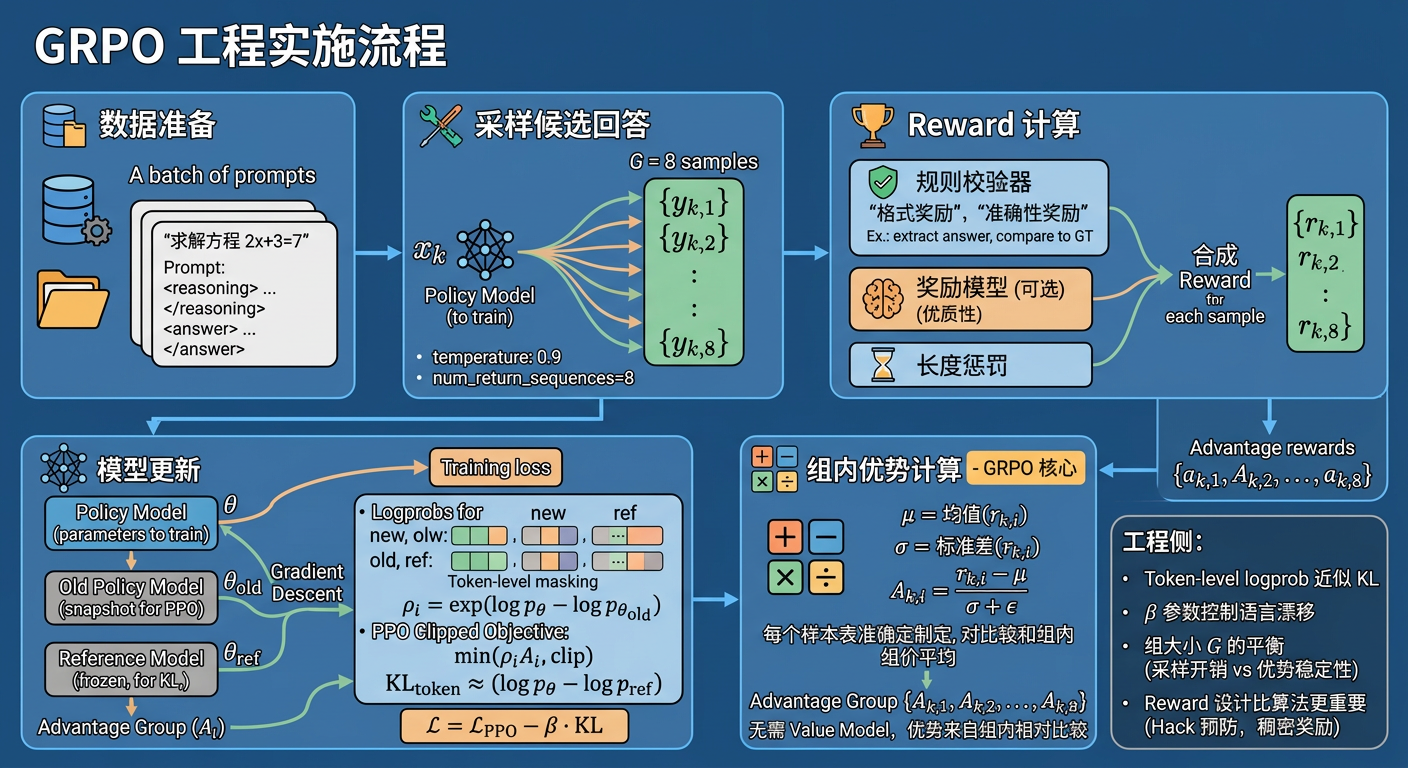

感觉除非
1. 调prompt不能解决问题
2. 数据太多了 不用浪费

参考

 1.https://github.com/stanford-cs336/spring2025-lectures
 
 2.https://zhuanlan.zhihu.com/p/1984387073625593089